In [85]:
import pandas as pd
import sys
from tqdm import tqdm
sys.path.append('..')
from grid_definition import define_grid
from summarize_percentiles import get_score
import os
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
sns.set()

In [10]:
os.chdir('..')

In [4]:
SELECTED_K = 275
SELECTED_METHOD = 'skew_gaussian'
SELECTED_DELTA_WINDOW = 2

In [32]:
k_scores = {}

for k, method, delta_window, daysahead, tag in tqdm(define_grid()):
    if (method, delta_window) != (SELECTED_METHOD, SELECTED_DELTA_WINDOW):
        continue
    if k not in k_scores:
        k_scores[k] = 0
    k_scores[k] +=  get_score(0, tag, daysahead)
    

100%|████████████████████████████████████████████████████████████████████████████| 2940/2940 [00:00<00:00, 28688.68it/s]


In [58]:
window_scores = {}

for k, method, delta_window, daysahead, tag in tqdm(define_grid()):
    if (method, k) != (SELECTED_METHOD, SELECTED_K):
        continue
    if delta_window not in window_scores:
        window_scores[delta_window] = 0
    window_scores[delta_window] +=  get_score(0, tag, daysahead)
    

100%|████████████████████████████████████████████████████████████████████████████| 2940/2940 [00:00<00:00, 26999.83it/s]


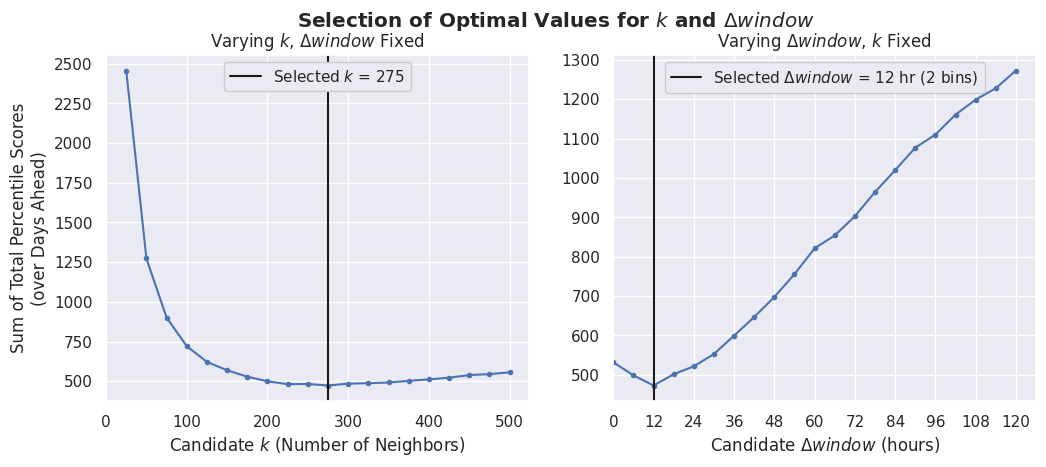

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(k_scores.keys(), k_scores.values(), '.-')
ax.axvline(SELECTED_K, color='k', label=f'Selected $k$ = {SELECTED_K}')
ax.set_xlim(0, ax.get_xlim()[1])
ax.set_xlabel('Candidate $k$ (Number of Neighbors)')
ax.set_ylabel('Sum of Total Percentile Scores\n(over Days Ahead)')
ax.legend(loc='upper center', framealpha=1)
ax.set_title('Varying $k$, $\Delta window$ Fixed')

ax = axes[1]
ax.plot(6 * np.array(list(window_scores.keys())), window_scores.values(), '.-',)
ax.axvline(6 * SELECTED_DELTA_WINDOW, color='k',  label=f'Selected $\Delta window$ = {6 * SELECTED_DELTA_WINDOW} hr ({SELECTED_DELTA_WINDOW} bins)')
ax.set_xlim(0, plt.xlim()[1])
ax.set_xlabel('Candidate $\Delta window$ (hours)')
ax.legend(loc='upper center', framealpha=1)
#ax.set_ylabel('Sum of Total Percentile\nScores over Days Ahead')
ax.set_xticks(6 * np.array(list(window_scores.keys())[::2]))
ax.set_title('Varying $\Delta window$, $k$ Fixed')

fig.suptitle('Selection of Optimal Values for $k$ and $\Delta window$', fontweight='bold')

fig.savefig('plots/optimal_selection.png', dpi=300)